In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Genearlly Lacking in unions
Agricultural_labor = pd.read_csv("/content/Occupation Report (Unions) - Agriculture (farms, ranches, aquaculture).csv")
Managers = pd.read_csv("/content/Occupation Report (Unions) - General managers.csv")
Private_investigators = pd.read_csv("/content/Occupation Report (Unions) - Private investigators_detectives.csv")

#Generally Strong Unionhoods
officers = pd.read_csv("/content/Occupation Report (Unions) - Police Officers .csv")
Registered_Nurses = pd.read_csv("/content/Occupation Report (Unions) - Registered Nurses.csv")
Teachers =pd.read_csv("/content/Occupation Report (Unions) - Teachers(secondary).csv")

all_data= [Agricultural_labor, Managers, Private_investigators, officers,
Registered_Nurses,Teachers]

In [ ]:
names_only =["Agricultural", "Management", "Private Investigators", "Officers", "Registerd Nurses", "Teachers"]

#Cleaning

In [ ]:
from numpy import percentile

def type_conversion(data):
  for x in list(data.columns):
    if data[x].dtype == 'O':
      data[x] = data[x].astype("string")

#Ensuring that columns without data are null values so they can be properlly dropped later
  for column in (list(data.columns)):
    if (column != "Area Name" and column != "Occupation") and data[column].dtype == "string":
        # Remove currency symbols, commas, and leading/trailing whitespace
        data[column] = data[column].str.replace("$", "").str.replace(",", "").str.strip()
        data[column] = pd.to_numeric(data[column], errors='coerce')

def column_cutting(data):
  data = data.loc[:, ['Area Name','Annual mean wage (2)','Employment (1)', 'Location Quotient', 'Employment per 1,000 jobs']]
  data.dropna(how='any', axis = 0, inplace = True)
  return data

def extract_state(data):
  data['State'] = data['Area Name'].apply(lambda x: x.split(' (')[0])
  return data


for x in range(len(all_data)):
  type_conversion(all_data[x])
  all_data[x] = column_cutting(all_data[x])
  all_data[x] = extract_state(all_data[x])
  all_data[x].loc[:, 'Occupation'] = (names_only[x])


all_data[0]

,Area Name,Annual mean wage (2),Employment (1),Location Quotient,"Employment per 1,000 jobs",State,Occupation
0,Alabama (01-00000),34990,1300,2.7,0.624,Alabama,Agricultural
1,Alaska (02-00000),51930,60,0.8,0.182,Alaska,Agricultural
2,Arizona (04-00000),40190,510,0.7,0.158,Arizona,Agricultural
3,Arkansas (05-00000),32870,410,1.4,0.322,Arkansas,Agricultural
4,California (06-00000),39790,5760,1.4,0.319,California,Agricultural
5,Colorado (08-00000),41990,1420,2.1,0.491,Colorado,Agricultural
6,Connecticut (09-00000),37640,130,0.3,0.079,Connecticut,Agricultural
7,Delaware (10-00000),37810,110,1.0,0.232,Delaware,Agricultural
8,Florida (12-00000),37210,740,0.3,0.075,Florida,Agricultural
9,Georgia (13-00000),35050,410,0.4,0.084,Georgia,Agricultural


In [ ]:
Agricultural_labor = all_data[0]
Managers = all_data[1]
Private_investigators = all_data[2]
officers = all_data[3]
Registered_Nurses = all_data[4]
Teachers = all_data[5]

In [ ]:
Teachers

,Area Name,Annual mean wage (2),Employment (1),Location Quotient,"Employment per 1,000 jobs",State,Occupation
0,Alabama (01-00000),58850,16480,1.1,7.879,Alabama,Teachers
1,Alaska (02-00000),80190,2780,1.3,8.673,Alaska,Teachers
2,Arizona (04-00000),65480,24100,1.1,7.540,Arizona,Teachers
3,Arkansas (05-00000),56820,12190,1.4,9.456,Arkansas,Teachers
4,California (06-00000),102040,96050,0.8,5.319,California,Teachers
5,Colorado (08-00000),69030,18160,0.9,6.280,Colorado,Teachers
6,Connecticut (09-00000),81370,15410,1.3,9.159,Connecticut,Teachers
7,Delaware (10-00000),71170,5410,1.6,11.349,Delaware,Teachers
8,District of Columbia (11-00000),82310,2960,0.6,4.182,District of Columbia,Teachers
9,Florida (12-00000),61880,47040,0.7,4.790,Florida,Teachers


#Seperating the Data

In [ ]:
low_unionhood = pd.concat([Agricultural_labor, Managers, Private_investigators], join= "inner")
low_unionhood['Unionhood_Level'] = "Low Unionhood"
low_unionhood.set_index(['Occupation', 'Area Name'], inplace=True)

high_unionhood = pd.concat([Registered_Nurses, officers, Teachers], join= "inner")
high_unionhood['Unionhood_Level'] = "High Unionhood"
high_unionhood.set_index(['Occupation', 'Area Name'], inplace=True)

combined_unionhood = pd.concat([Agricultural_labor, Managers, Private_investigators, Registered_Nurses, officers, Teachers], join = "inner")
combined_unionhood.set_index(['Occupation', 'Area Name'], inplace = True)


In [ ]:
high_unionhood

Annual mean wage (2)  \
Occupation       Area Name                                        
Registerd Nurses Alabama (01-00000)                       74970   
                 Alaska (02-00000)                       112040   
                 Arizona (04-00000)                       95230   
                 Arkansas (05-00000)                      77720   
                 California (06-00000)                   148330   
...                                                         ...   
Teachers         Virginia (51-00000)                      71260   
                 Washington (53-00000)                    95830   
                 West Virginia (54-00000)                 54360   
                 Wisconsin (55-00000)                     64370   
                 Wyoming (56-00000)                       65210   

                                           Employment (1)  Location Quotient  \
Occupation       Area Name                                                     
Registerd Nurses Alabama (01-00000)                 53340                1.2   
                 Alaska (02-00000)                   7040                1.0   
                 Arizona (04-00000)                 64430                0.9   
                 Arkansas (05-00000)                28320                1.0   
                 California (06-00000)             326720                0.9   
...                                                   ...                ...   
Teachers         Virginia (51-00000)                28580                1.0   
                 Washington (53-00000)              14730                0.6   
                 West Virginia (54-00000)            3650                0.8   
                 Wisconsin (55-00000)               18060                0.9   
                 Wyoming (56-00000)                  1830                0.9   

                                           Employment per 1,000 jobs  \
Occupation       Area Name                                             
Registerd Nurses Alabama (01-00000)                           25.503   
                 Alaska (02-00000)                            21.920   
                 Arizona (04-00000)                           20.155   
                 Arkansas (05-00000)                          21.970   
                 California (06-00000)                        18.093   
...                                                              ...   
Teachers         Virginia (51-00000)                           7.031   
                 Washington (53-00000)                         4.162   
                 West Virginia (54-00000)                      5.200   
                 Wisconsin (55-00000)                          6.177   
                 Wyoming (56-00000)                            6.586   

                                                   State Unionhood_Level  
Occupation       Area Name                                                
Registerd Nurses Alabama (01-00000)              Alabama  High Unionhood  
                 Alaska (02-00000)                Alaska  High Unionhood  
                 Arizona (04-00000)              Arizona  High Unionhood  
                 Arkansas (05-00000)            Arkansas  High Unionhood  
                 California (06-00000)        California  High Unionhood  
...                                                  ...             ...  
Teachers         Virginia (51-00000)            Virginia  High Unionhood  
                 Washington (53-00000)        Washington  High Unionhood  
                 West Virginia (54-00000)  West Virginia  High Unionhood  
                 Wisconsin (55-00000)          Wisconsin  High Unionhood  
                 Wyoming (56-00000)              Wyoming  High Unionhood  

[159 rows x 6 columns]

In [ ]:
# Making Graphs

In [ ]:
avg_wage_low_unionhood = low_unionhood['Annual mean wage (2)'].mean()
avg_wage_high_unionhood = high_unionhood['Annual mean wage (2)'].mean()


unionhood_avg_wages = pd.DataFrame({
    'Unionhood': ['Low Unionhood', 'High Unionhood'],
    'Average Annual Wage': [avg_wage_low_unionhood, avg_wage_high_unionhood]
})

print(unionhood_avg_wages)

        Unionhood  Average Annual Wage
0   Low Unionhood         76211.907895
1  High Unionhood         77791.761006


#

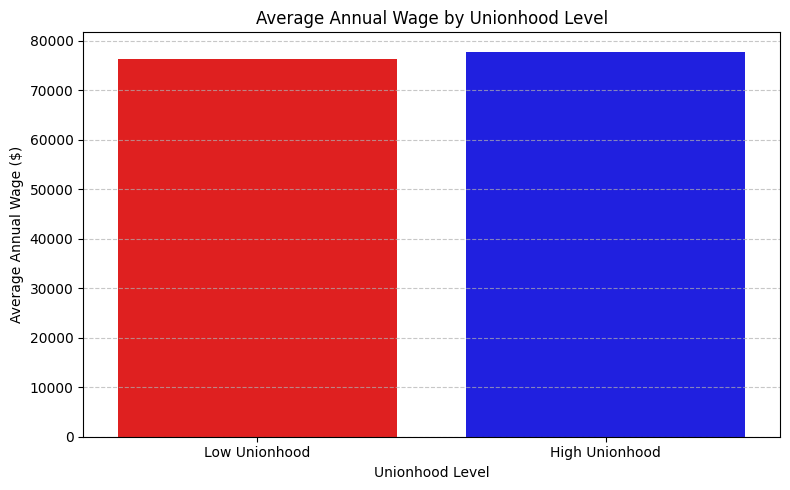

In [291]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Unionhood', y='Average Annual Wage', data=unionhood_avg_wages, palette={'Low Unionhood': 'red', 'High Unionhood': 'blue'}, hue='Unionhood', legend=False)
plt.title('Average Annual Wage by Unionhood Level')
plt.xlabel('Unionhood Level')
plt.ylabel('Average Annual Wage ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("Low unionhood Vs High Unionhood")
plt.show()

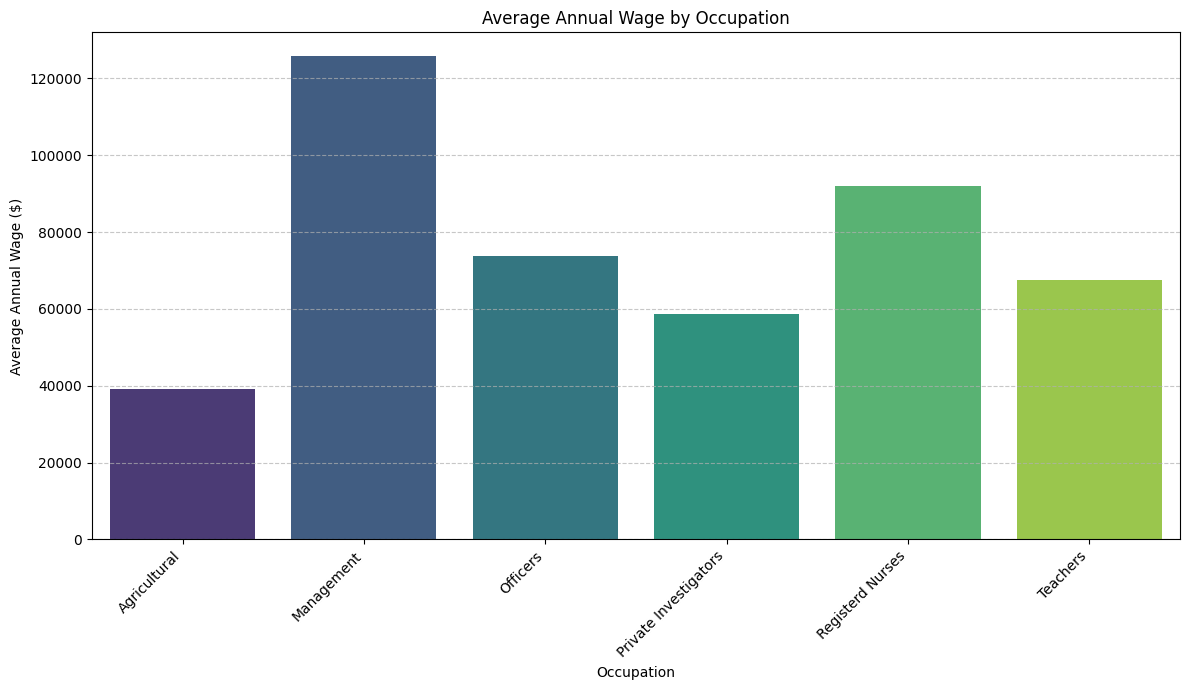

In [ ]:
occupationAvg = combined_unionhood.groupby('Occupation')['Annual mean wage (2)'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Occupation', y='Annual mean wage (2)', data=occupationAvg, palette='viridis', hue='Occupation', legend=False)
plt.title('Average Annual Wage by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Annual Wage ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Average Annual Wage by Occupation')
plt.show()

### Visualizing Top 5 and Bottom 5 State Wages regardless of unionhood

In [ ]:
bottom5_states = combined_unionhood.groupby('State')['Annual mean wage (2)'].mean().sort_values().head(5)
top5_states = combined_unionhood.groupby('State')['Annual mean wage (2)'].mean().sort_values(ascending = False).head(5)
top5_states


,Annual mean wage (2)
State,
District of Columbia,115267.5
California,105376.666667
Washington,98246.666667
New York,97161.666667
New Jersey,95163.333333


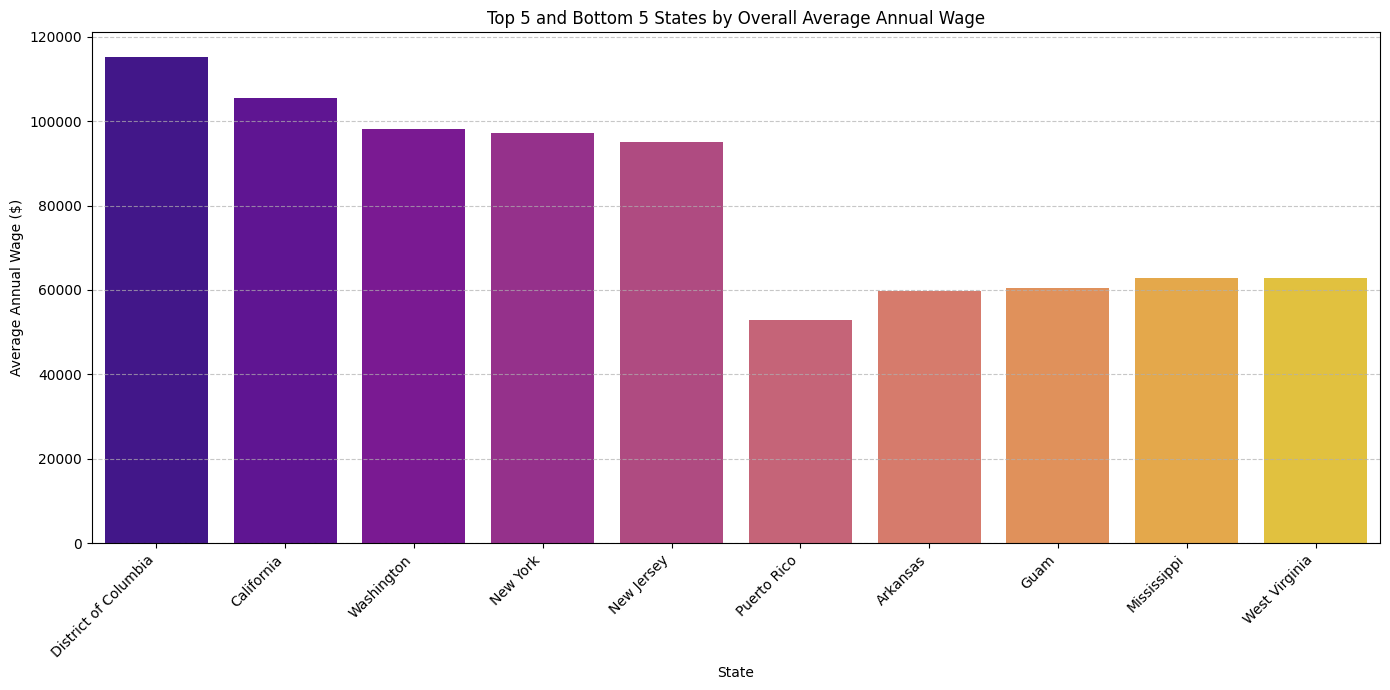

In [ ]:

# Concatenate the top 5 and bottom 5 DataFrames
combinedtop_bottom5 = pd.DataFrame(pd.concat([top5_states, bottom5_states]))

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='State', y='Annual mean wage (2)', data=combinedtop_bottom5,
            palette='plasma', hue='State', legend=False)
plt.title('Top 5 and Bottom 5 States by Overall Average Annual Wage')
plt.xlabel('State')
plt.ylabel('Average Annual Wage ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("Top5 and Bottom 5 states by wages")
plt.show()

### Visualizing Top 5 and Bottom 5 State Wages by Unionhood Level (Line Plot)

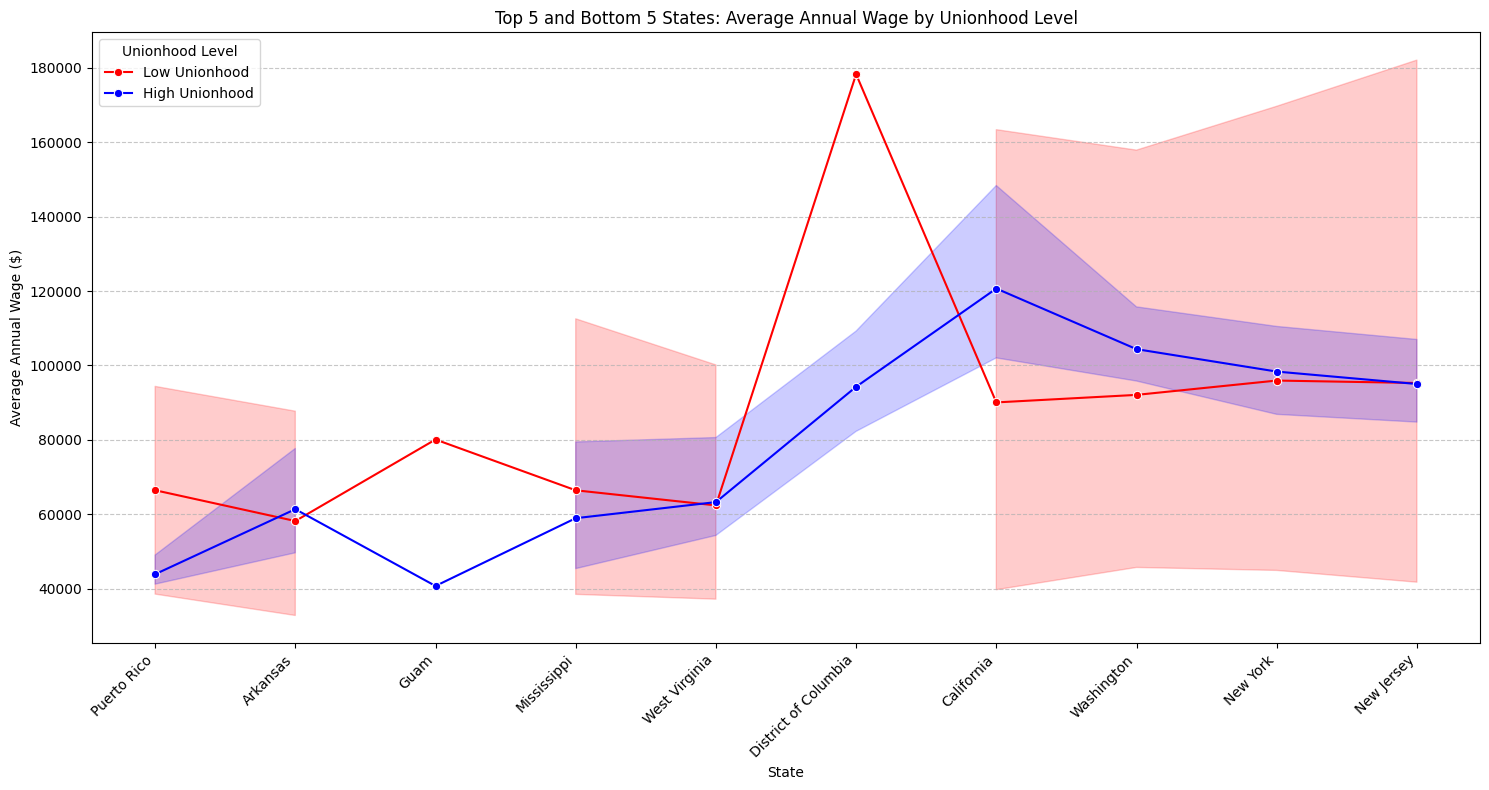

In [ ]:
#Make top and bottom state series Dataframes
bottom5_states_df = pd.DataFrame(bottom5_states).reset_index()
top5_states_df = pd.DataFrame(top5_states).reset_index()


#find the Wages in the low wage having and high wage having states for both unions and non unions
lowUnionbottmoStWage = low_unionhood[['Annual mean wage (2)', 'Unionhood_Level', 'State']].merge(bottom5_states_df, how= "right", on= "State")
lowUnionhighStWage = low_unionhood[['Annual mean wage (2)', 'Unionhood_Level', 'State']].merge(top5_states_df, how= "right", on= "State")


highUnionbottmoStWage = high_unionhood[['Annual mean wage (2)', 'Unionhood_Level', 'State']].merge(bottom5_states_df, how= "right", on= "State")
highUnionHighStWage =high_unionhood[['Annual mean wage (2)', 'Unionhood_Level', 'State']].merge(top5_states_df, how= "right", on= "State")

combined5 = pd.DataFrame(pd.concat([lowUnionbottmoStWage,lowUnionhighStWage, highUnionbottmoStWage, highUnionHighStWage]))

# Rename the columns
combined5 = combined5.rename(columns={'Annual mean wage (2)_x': 'wage', 'Annual mean wage (2)_y': 'overall avg wage'})

# Create the line plot
plt.figure(figsize=(15, 8))
sns.lineplot(x='State', y='wage', hue='Unionhood_Level',
             data=combined5, marker='o', palette={'Low Unionhood': 'red', 'High Unionhood': 'blue'})
plt.title('Top 5 and Bottom 5 States: Average Annual Wage by Unionhood Level')
plt.xlabel('State')
plt.ylabel('Average Annual Wage ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Unionhood Level')
plt.tight_layout()
plt.savefig("Unionhood in Top & Bottom 5 States")
plt.show()

### Location Quotient by Wage for Low and High Unionhood

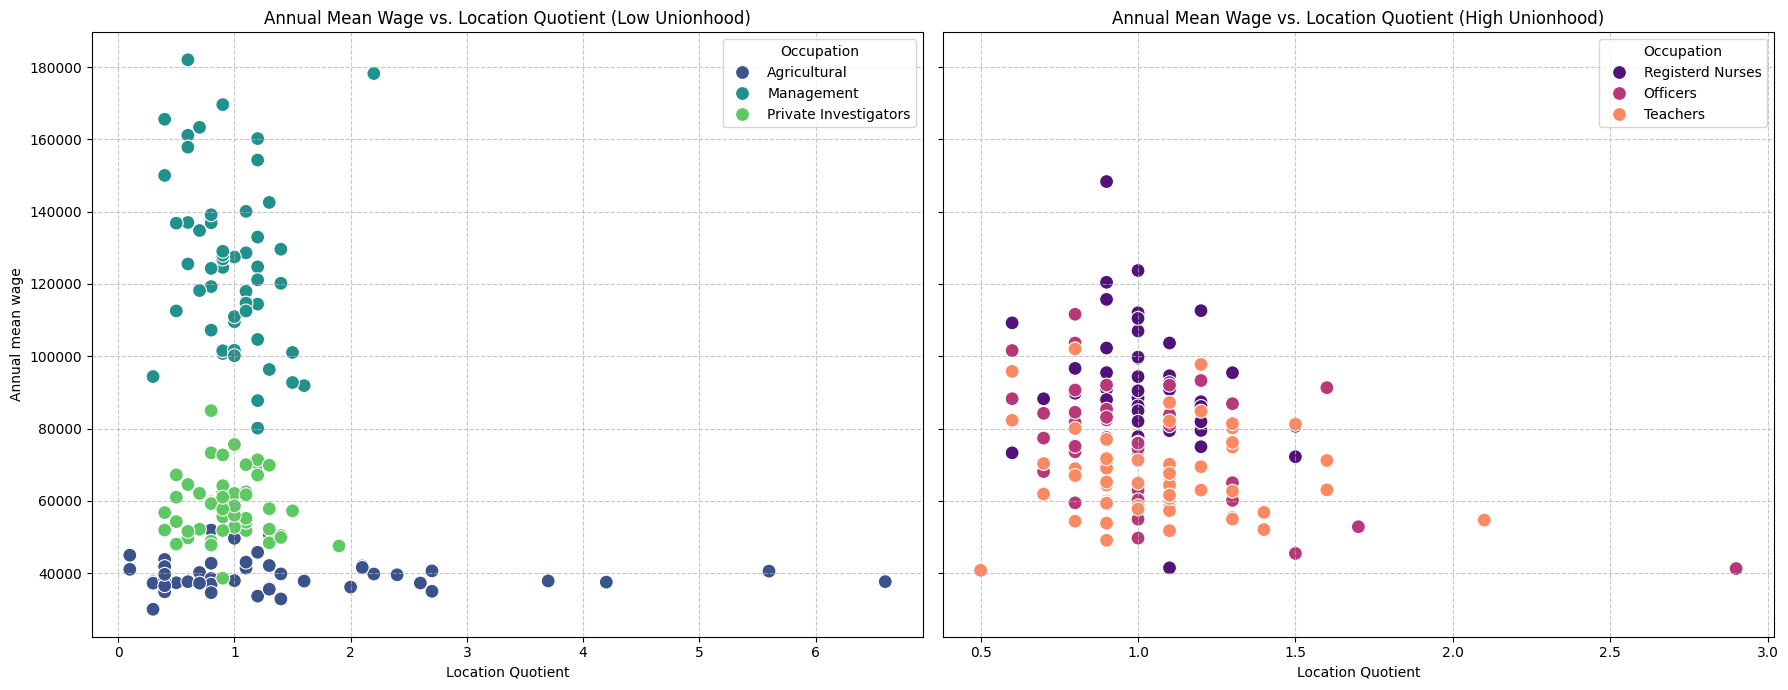

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot for Low Unionhood
sns.scatterplot(
    x='Location Quotient' ,
    y= 'Annual mean wage (2)',
    data=low_unionhood.reset_index(),
    hue='Occupation',
    palette='viridis',
    s=100,
    ax=axes[0],
    legend='full'
)
axes[0].set_title('Annual Mean Wage vs. Location Quotient (Low Unionhood)')
axes[0].set_xlabel('Location Quotient')
axes[0].set_ylabel('Annual mean wage')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for High Unionhood
sns.scatterplot(
    x='Location Quotient',
    y='Annual mean wage (2)',
    data=high_unionhood.reset_index(),
    hue='Occupation',
    palette='magma',
    s=100,
    ax=axes[1],
    legend='full'
)
axes[1].set_title('Annual Mean Wage vs. Location Quotient (High Unionhood)')
axes[1].set_xlabel('Location Quotient')
axes[1].set_ylabel('Annual mean wage')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Location Quotient Vs Wage")
plt.show()


### Employment per 1,000 Jobs vs. Annual Mean Wage by Unionhood Level

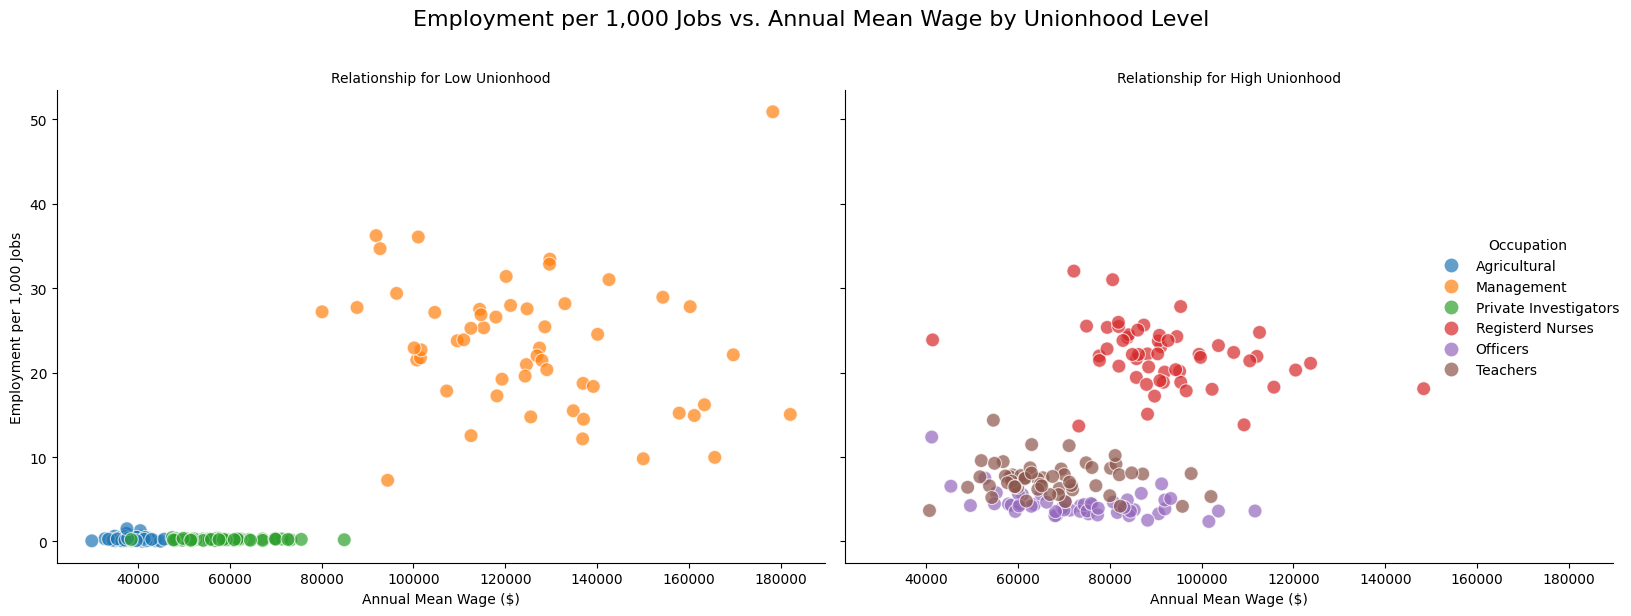

In [ ]:

plot_data = pd.concat([low_unionhood.reset_index(), high_unionhood.reset_index()], ignore_index=True)


g = sns.relplot(
    x='Annual mean wage (2)',
    y='Employment per 1,000 jobs',
    data=plot_data,
    col='Unionhood_Level',
    hue='Occupation',
    palette='tab10',
    kind='scatter',
    height=6,
    aspect=1.2,
    s=100,
    alpha=0.7
)


g.set_axis_labels('Annual Mean Wage ($)', 'Employment per 1,000 Jobs')
g.set_titles('Relationship for {col_name}')
plt.suptitle('Employment per 1,000 Jobs vs. Annual Mean Wage by Unionhood Level',
             y=1.02,
             fontsize=16)
plt.tight_layout()
plt.savefig("Employment Vs wage")
plt.show()